In [2]:
import pandas as pd

df = pd.read_csv('../medical_insurance.csv')
df.head()

,person_id,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,...,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
0,75722,52,Female,North,Suburban,22700.0,Doctorate,Married,Retired,3,...,0,1,0,1,0,2,0,1,0,0
1,80185,79,Female,North,Urban,12800.0,No HS,Married,Employed,3,...,0,1,1,0,0,1,0,1,1,0
2,19865,68,Male,North,Rural,40700.0,HS,Married,Retired,5,...,0,0,1,1,0,2,1,0,1,0
3,76700,15,Male,North,Suburban,15600.0,Some College,Married,Self-employed,5,...,0,0,0,1,0,0,1,0,0,0
4,92992,53,Male,Central,Suburban,89600.0,Doctorate,Married,Self-employed,2,...,0,1,0,2,0,1,1,0,1,0


In [3]:
import numpy as np

df['log_cost'] = np.log1p(df['annual_medical_cost'])
df[['annual_medical_cost', 'log_cost']].head()

,annual_medical_cost,log_cost
0,6938.06,8.844922
1,1632.61,7.398548
2,7661.01,8.944030
3,5130.27,8.543108
4,1700.73,7.439401


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score

X = df.select_dtypes(include='number').drop(columns=['annual_medical_cost'])
y = df['annual_medical_cost']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = Ridge()
model.fit(X_train, y_train)

preds = model.predict(X_test)

print("R2:", r2_score(y_test, preds))

R2: 0.9458758009496144


In [5]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor()
rf.fit(X_train, y_train)

print("RF R2:", r2_score(y_test, rf.predict(X_test)))

RF R2: 0.9997825582193133


In [2]:
import sys
import os

# Get the current working directory
current_dir = os.getcwd()

# Add the parent directory (root) to the python path
sys.path.append(os.path.abspath(os.path.join(current_dir, '..')))

# Now try the imports again
from src.utils import load_object

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from src.utils import load_object

# Set plot style
plt.style.use('ggplot')
sns.set_palette("viridis")

In [4]:
# 1. Load Data and Artifacts
# We load the test set to evaluate how the models perform on unseen data
test_df = pd.read_csv('../artifacts/test.csv')
target_col = 'annual_medical_cost'

# Load the experiment results summary
results = load_object('../artifacts/final_experiment_results.pkl')

Text(0.5, 1.0, 'Comparative Performance Analysis Across Tiers')

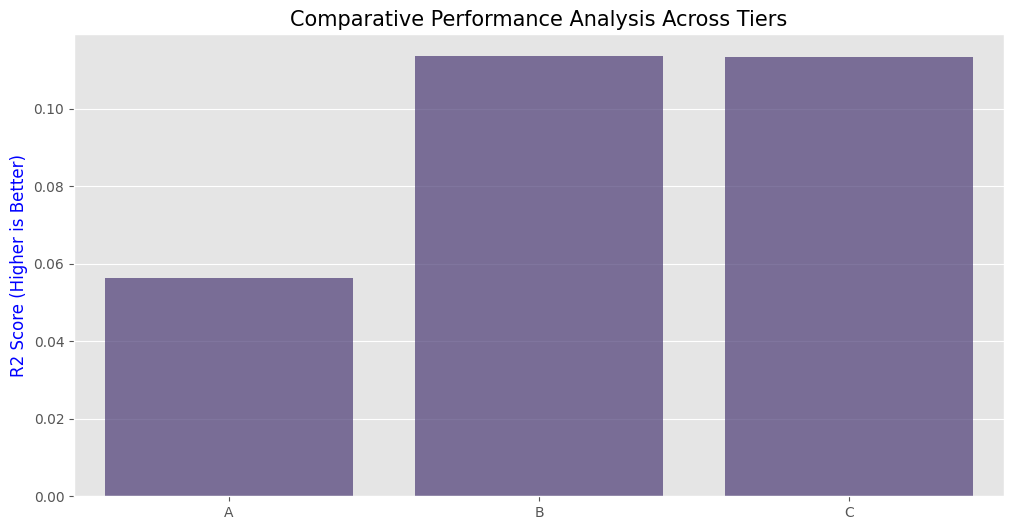

In [5]:
# 2. Comparative Analysis of Tiers (A vs B vs C)
tiers = ['A', 'B', 'C']
r2_scores = [results[t]['Test R2'] for t in tiers]
rmse_values = [results[t]['Test RMSE Real'] for t in tiers]

fig, ax1 = plt.subplots(figsize=(12, 6))

# Bar plot for R2
sns.barplot(x=tiers, y=r2_scores, ax=ax1, alpha=0.7)
ax1.set_ylabel('R2 Score (Higher is Better)', color='b', fontsize=12)
ax1.set_title('Comparative Performance Analysis Across Tiers', fontsize=15)

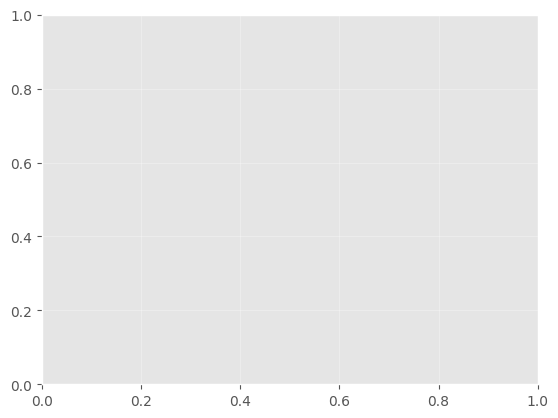

Insight: The leap from Tier A (0.0564) to Tier B (0.1135) represents a significant information gain.
This proves that past utilization is a stronger predictor of cost than baseline health biometrics alone.


In [6]:
# Line plot for RMSE on secondary axis
ax2 = ax1.twinx()
sns.lineplot(x=tiers, y=rmse_values, marker='o', color='r', linewidth=2.5, ax=ax2)
ax2.set_ylabel('RMSE in Dollars (Lower is Better)', color='r', fontsize=12)

plt.grid(True, alpha=0.3)
plt.show()

print(f"Insight: The leap from Tier A ({r2_scores[0]:.4f}) to Tier B ({r2_scores[1]:.4f}) represents a significant information gain.")
print("This proves that past utilization is a stronger predictor of cost than baseline health biometrics alone.")

In [7]:
# 3. Deep Dive into Tier C (The Final Winning Model)
# Load the artifacts for Tier C
preprocessor_meta = load_object('../artifacts/preprocessor_C.pkl')
model_c = load_object('../artifacts/model_C.pkl')

# Extract actual preprocessor and feature names
preprocessor = preprocessor_meta['preprocessor']
feature_names = preprocessor_meta['features']

In [8]:
# Prepare the test data (Transforming raw data using the saved preprocessor)
# We must apply the same feature engineering (MAP) as done in training
test_df['MAP'] = (2 * test_df['diastolic_bp'] + test_df['systolic_bp']) / 3
X_test_raw = test_df.drop(columns=[target_col, 'systolic_bp', 'diastolic_bp'], errors='ignore')
y_test = test_df[target_col]

X_test_transformed = preprocessor.transform(X_test_raw)

In [9]:
# 4. Model Evaluation & Error Analysis
y_pred = model_c.predict(X_test_transformed)

# Metrics Calculation
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"\n--- Tier C Model Evaluation ---")
print(f"R2 Score: {r2:.4f}")
print(f"Mean Absolute Error: ${mae:.2f}")
print(f"Root Mean Squared Error: ${rmse:.2f}")


--- Tier C Model Evaluation ---
R2 Score: 0.1134
Mean Absolute Error: $1665.76
Root Mean Squared Error: $2953.72


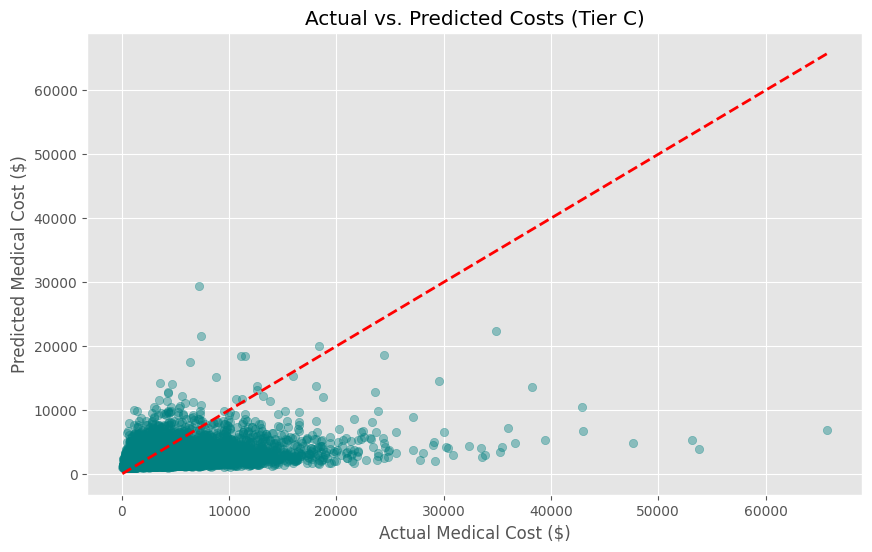

In [10]:
# 5. Visualizing Predictions vs Actuals
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.4, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Medical Cost ($)')
plt.ylabel('Predicted Medical Cost ($)')
plt.title('Actual vs. Predicted Costs (Tier C)')
plt.show()

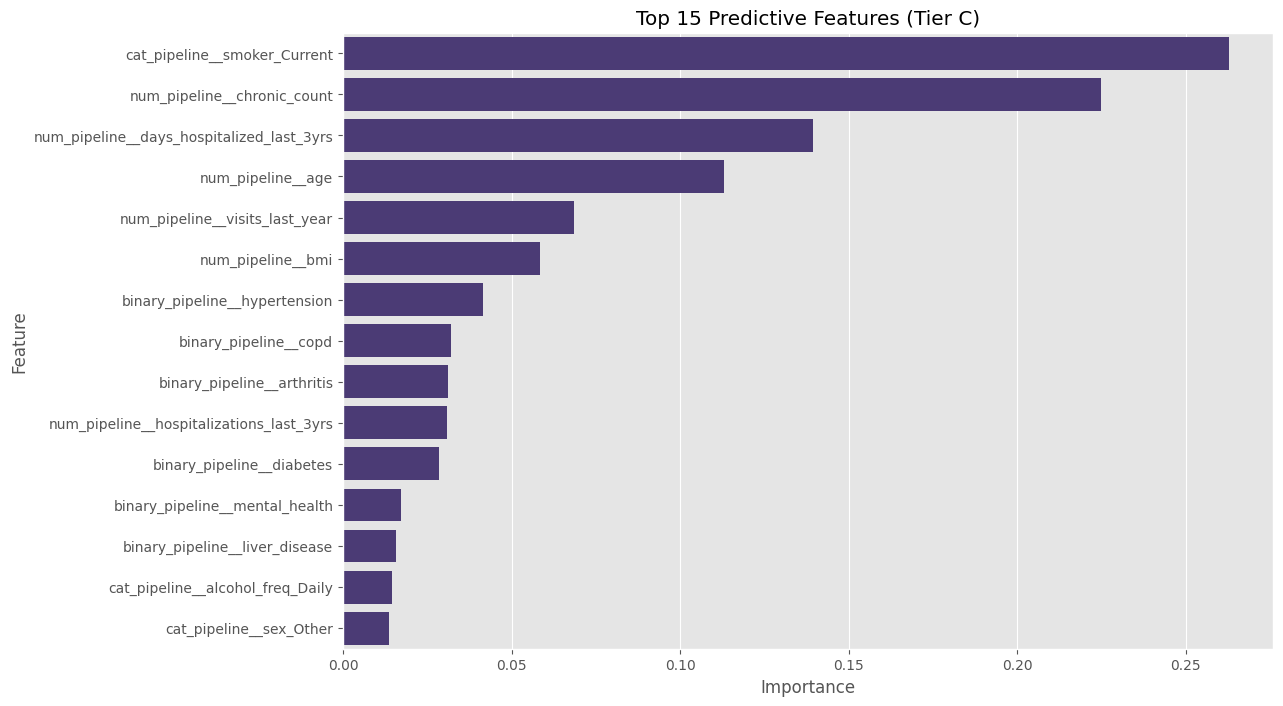


Notebook finalized. Analysis of experimental tiers and model deployment readiness complete.


In [11]:
# 6. Feature Importance (For Ridge/Linear Models)
# Extracting weights to see what drives the insurance costs
if hasattr(model_c.regressor_, 'coef_'):
    importance = model_c.regressor_.coef_
    feat_importance = pd.DataFrame({'Feature': feature_names, 'Importance': importance})
    feat_importance = feat_importance.sort_values(by='Importance', ascending=False).head(15)

    plt.figure(figsize=(12, 8))
    sns.barplot(x='Importance', y='Feature', data=feat_importance)
    plt.title('Top 15 Predictive Features (Tier C)')
    plt.show()

print("\nNotebook finalized. Analysis of experimental tiers and model deployment readiness complete.")